This version of the example uses lmfit (https://lmfit.github.io/lmfit-py/) with an explicitly defined objective function

In [1]:
import numpy as np
from lmfit import minimize, Parameters
import matplotlib.pyplot as plt

In [2]:
# Generate example data according to an exponential PDF
np.random.seed(42)
lambda_=3.14159   # lambda is a keyword, so use lambda_ instead!
x_true = np.random.exponential(scale=lambda_, size=1000)

# Create histogram of the data
range=(0.0,4.0)
counts, bin_edges = np.histogram(x_true, bins=50, range=range, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errs = np.sqrt(counts)

<ErrorbarContainer object of 3 artists>

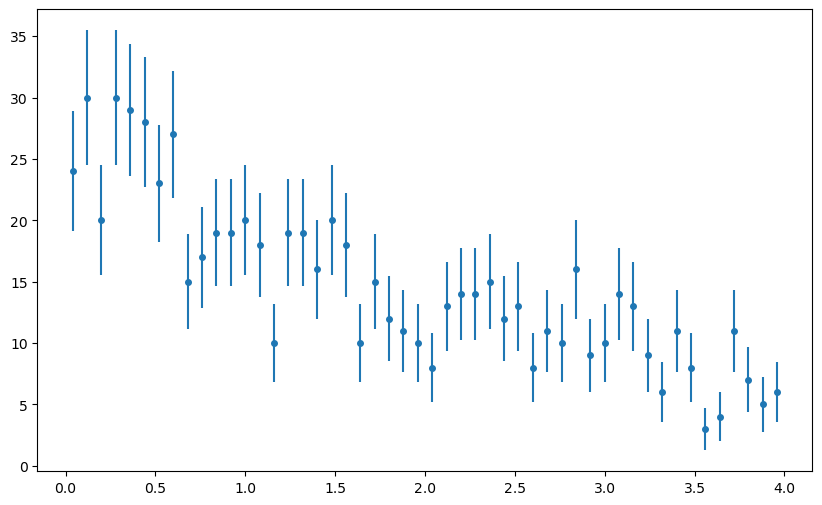

In [3]:
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, counts, yerr=errs, fmt='o', label='Data', markersize=4)

In [4]:
# Define the model function
def expo(x, scale, lambda_):
    return scale * np.exp(-x/lambda_)

# Define the objective function to minimize (chi-square)
# returns the 'residual array'
# def objective(params, x, data, errs):
#     scale = params['scale']
#     lambda_ = params['lambda_']
    
#     model = expo(x, scale, lambda_)
#     return (model - data) / errs 
from scipy.special import gammaln
def objective(params, x, data, errs):
    scale = params['scale']
    lambda_ = params['lambda_']
    
    model = expo(x, scale, lambda_)
    model[model <= 0] = 1e-10
    
    nll = model - data * np.log(model) + gammaln(data + 1)
    
    return np.sum(nll)

# Set up parameters with initial guesses
params = Parameters()
params.add('scale', value=np.max(counts))
params.add('lambda_', value=2)

Check our guess for the starting parameter values

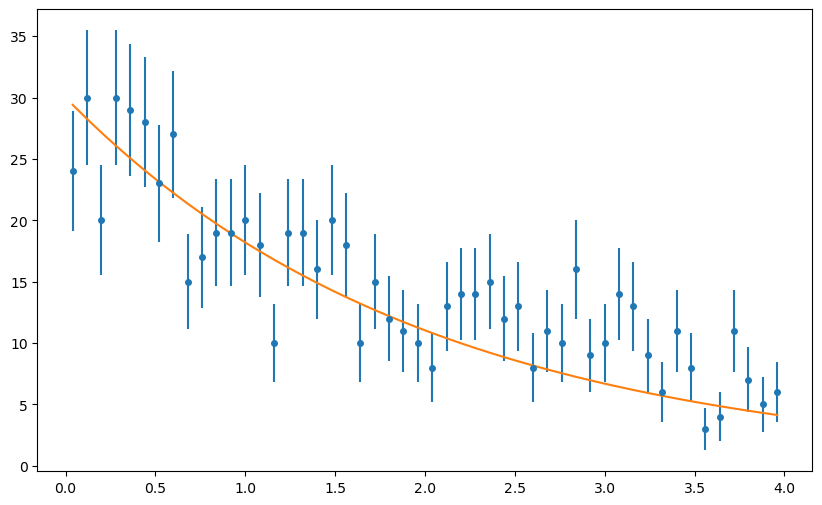

In [5]:
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, counts, yerr=errs, fmt='o', label='Data', markersize=4)
plt.plot(bin_centers,expo(bin_centers,params['scale'].value,params['lambda_'].value))

The initial guess for the paraemter values looks pretty good.  Therfore the minimzer should be able to converge to a good minimum.

In [6]:
# Perform the fit
result = minimize(objective, params, args=(bin_centers, counts, errs), method='powell')

In [7]:
result.chisqr

np.float64(17092.13000043086)


=== NLL Fit Results ===
scale:   27.229 (stderr not calculated)
lambda:  2.828 (stderr not calculated)

NLL at minimum: 17092.1
Degrees of freedom: -1


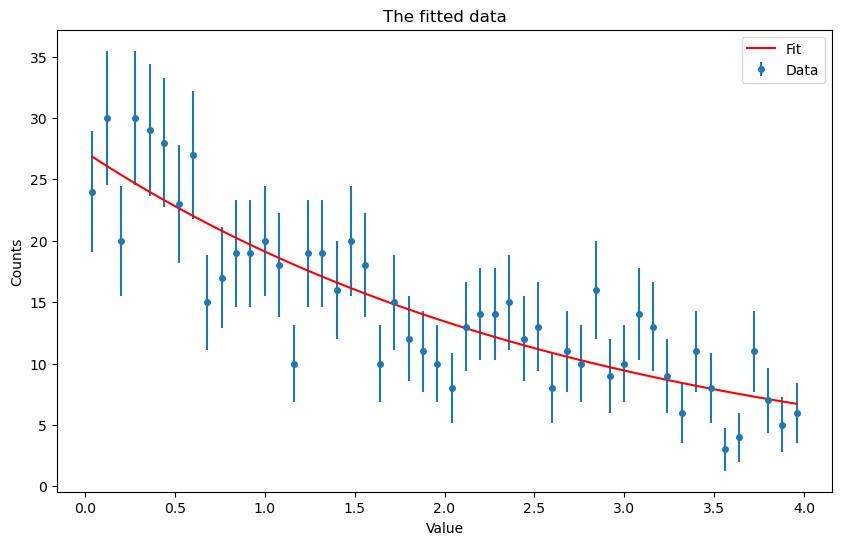

In [9]:
# Calculate the best fit curve
best_fit = expo(bin_centers, result.params['scale'].value, result.params['lambda_'].value)

# get the chi-square and reduced chi-square
chisq = result.chisqr
red_chisq = result.redchi
nDOF = result.nfree

# Plot the results
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), 
             fmt='o', label='Data', markersize=4)
plt.plot(bin_centers, best_fit, 'r-', label='Fit')
plt.xlabel('Value')
plt.ylabel('Counts')
plt.legend()
plt.title('The fitted data')

# Print fit results
print('\n=== NLL Fit Results ===')
print(f"scale:   {result.params['scale'].value:.3f}", end='')
if result.params['scale'].stderr:
    print(f" ± {result.params['scale'].stderr:.3f}")
else:
    print(" (stderr not calculated)")
    
print(f"lambda:  {result.params['lambda_'].value:.3f}", end='')
if result.params['lambda_'].stderr:
    print(f" ± {result.params['lambda_'].stderr:.3f}")
else:
    print(" (stderr not calculated)")

print(f'\nNLL at minimum: {result.chisqr:.1f}')
print(f'Degrees of freedom: {result.nfree}')

plt.show()

In [10]:
# using the internal fit report
from lmfit import fit_report
print(fit_report(result))

[[Fit Statistics]]
    # fitting method   = Powell
    # function evals   = 95
    # data points      = 1
    # variables        = 2
    chi-square         = 17092.1300
    reduced chi-square = 17092.1300
    Akaike info crit   = 13.7463734
    Bayesian info crit = 9.74637340
##  Warning: uncertainties could not be estimated:
[[Variables]]
    scale:    27.2289705 (init = 30)
    lambda_:  2.82831422 (init = 2)
